## Breakpoint for attempt number 2

In [77]:
import numpy as np
import pandas as pd

# CSV files exported from Earth Engine (same folder as this notebook)
FILES = {
    'era5land': '/Users/sophiethomas/Desktop/MDP/Climatology/Sisal_ERA5Land_daily_all.csv',
    'era5':     '/Users/sophiethomas/Desktop/MDP/Climatology/Sisal_ERA5_daily_all.csv',
    'hycom':    '/Users/sophiethomas/Desktop/MDP/Climatology/Sisal_HYCOM_daily_all.csv',
}

# kind:    'linear'   ordinary variable (averaged)
#          'flux'     daily amount, e.g. mm/day (summed to monthly totals)
#          'circular' direction in degrees (averaged as a vector)
# monthly: optional override of the monthly aggregation ('mean', 'sum', 'max')
# Units are already converted in the Earth Engine export.
VARIABLES = {
    # ERA5-Land, two inland cells (choose CELL = 'c1' or 'c2')
    't2m_c':       dict(src='era5land', label='2 m air temperature (daily mean)', unit='°C',   kind='linear'),
    't2m_min_c':   dict(src='era5land', label='2 m air temperature (daily min)',  unit='°C',   kind='linear'),
    't2m_max_c':   dict(src='era5land', label='2 m air temperature (daily max)',  unit='°C',   kind='linear'),
    'skin_t_c':    dict(src='era5land', label='Skin temperature',                  unit='°C',   kind='linear'),
    'precip_mm':   dict(src='era5land', label='Precipitation',                     unit='mm',   kind='flux'),
    'evap_mm':     dict(src='era5land', label='Actual evaporation',                unit='mm',   kind='flux'),
    'pot_evap_mm': dict(src='era5land', label='Potential evaporation',             unit='mm',   kind='flux'),
    'evap_gap_mm': dict(src='era5land', label='Evaporation gap (potential - actual)', unit='mm', kind='flux'),
    # ERA5, sea cell
    'wind_u_ms':       dict(src='era5', label='10 m wind, eastward component',  unit='m/s',  kind='linear'),
    'wind_v_ms':       dict(src='era5', label='10 m wind, northward component', unit='m/s',  kind='linear'),
    'wind_speed_ms':   dict(src='era5', label='10 m wind speed',                unit='m/s',  kind='linear'),
    'sst_c':           dict(src='era5', label='Sea surface temperature (ERA5)', unit='°C',   kind='linear'),
    'hs_mean_m':       dict(src='era5', label='Significant wave height (mean)', unit='m',    kind='linear'),
    'hs_max_m':        dict(src='era5', label='Significant wave height (max)',  unit='m',    kind='linear', monthly='max'),
    'tp_mean_s':       dict(src='era5', label='Peak wave period',               unit='s',    kind='linear'),
    'wave_dir_deg':    dict(src='era5', label='Mean wave direction (from)',     unit='°',    kind='circular'),
    'wave_power_kw_m': dict(src='era5', label='Wave power',                     unit='kW/m', kind='linear'),
    # HYCOM, one pixel
    'temp_surface_c':      dict(src='hycom', label='Sea surface temperature (HYCOM)', unit='°C',  kind='linear'),
    'temp_bottom_c':       dict(src='hycom', label='Bottom temperature',              unit='°C',  kind='linear'),
    'salinity_surface_psu':dict(src='hycom', label='Surface salinity',                unit='PSU', kind='linear'),
    'salinity_bottom_psu': dict(src='hycom', label='Bottom salinity',                 unit='PSU', kind='linear'),
}


def load_series(var, cell='c1'):
    """Daily series on a complete daily index (missing days are NaN)."""
    info = VARIABLES[var]
    path = FILES[info['src']]
    df = pd.read_csv(path, parse_dates=['date'])
    col = f'{var}_{cell}' if info['src'] == 'era5land' else var
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in {path}. Available: {list(df.columns)}")

    if info['src'] == 'hycom' and 'bottom_level_m' in df.columns:
        levels = df['bottom_level_m'].dropna().unique()
        print(f'HYCOM bottom level(s) used: {sorted(levels)} m'
              + ('  <-- should be a single value' if len(levels) > 1 else ''))

    s = df.set_index('date')[col].sort_index()
    s = s[~s.index.duplicated()]
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq='D'))
    if var.startswith('salinity'):
        s[s < 30] = np.nan      # HYCOM fill values (raw 0 -> 20 PSU)
    s.name = var
    # if VAR.startswith('salinity'):
    #    s = s['1993':'2012']        # one HYCOM model version only

    n_years = (s.index[-1] - s.index[0]).days / 365.25
    print(f'{info["label"]} [{col}]: {s.index[0].date()} to {s.index[-1].date()}, '
          f'{n_years:.1f} years, {s.isna().sum()} missing days')
    if n_years < 20:
        print(f'WARNING: only {n_years:.0f} years of data. Trends and percentiles are '
              'not robust; use this run to test the pipeline, not to report results.')
    return s, info


In [78]:
from scipy import stats

VAR  = 't2m_min_c'      # any key from VARIABLES except 'wave_dir_deg'
CELL = 'c1'         # ERA5-Land only: rerun with 'c2' to cross-check
WINDOW, SMOOTH = 11, 31    # days: percentile window and smoothing
DETREND = False             # None = automatic (only if >= 20 years of data)

s, info = load_series(VAR, CELL)
if info['kind'] == 'circular':
    raise ValueError('Directions cannot be detrended or put into percentiles. '
                     'Use Climatology_plots.ipynb for wave direction.')

TAG   = CELL if info['src'] == 'era5land' else info['src']
UNIT  = info['unit'] + ('/day' if info['kind'] == 'flux' else '')
valid = s.dropna()
YEAR0, YEAR1 = s.index[0].year, s.index[-1].year
N_YEARS = (s.index[-1] - s.index[0]).days / 365.25
if DETREND is None:
    DETREND = N_YEARS >= 20

# --- 1. linear trend on daily anomalies (seasonal cycle removed) -----------
# --- day-of-year index, leap years collapsed onto a 365-day calendar -------
def doy365(idx):
    doy = idx.dayofyear.values.copy()
    doy[idx.is_leap_year & (doy > 59)] -= 1      # 29 Feb shares day 59
    return doy

doy_all  = doy365(s.index)
raw_clim = pd.Series(s.values, index=doy_all).groupby(level=0).mean()
anom     = s - raw_clim.reindex(doy_all).values

t_all = (s.index - s.index[0]).days.values / 365.25
t     = t_all[anom.notna().values]
slope, icpt = np.polyfit(t, anom.dropna().values, 1)
print(f'daily-fit trend: {slope*10:.3f} {UNIT} per decade')

# --- 2. trend with uncertainty, on annual means (years >= 90% complete) ----
g   = s.resample('YE')
ann = g.mean()[g.count() >= 329]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:.3f} '
          f'± {res.stderr*10*1.96:.3f} {UNIT} per decade (95%)')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# --- 3. detrend (keeps the mean level) --------------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. day-of-year index, leap years collapsed onto a 365-day calendar ----
doy = doy365(x.index)
r   = pd.Series(x.values, index=doy).dropna()

# --- 5. WINDOW-day climatology, wrapping at the year boundary --------------
half = WINDOW // 2
clim = {}
for d in range(1, 366):
    w = [(d + k - 1) % 365 + 1 for k in range(-half, half + 1)]
    v = r[r.index.isin(w)].values
    clim[d] = (v.mean(), np.percentile(v, 10), np.percentile(v, 90))
clim = pd.DataFrame(clim, index=['mean', 'p10', 'p90']).T
print(f'values per day-of-year window: ~{len(r) * WINDOW // 365}')

# --- 5b. precipitation: wet-day frequency and intensity --------------------
WET = 1.0   # mm, ETCCDI wet-day threshold
if VAR == 'precip_mm':
    wet = {}
    for d in range(1, 366):
        w  = [(d + k - 1) % 365 + 1 for k in range(-half, half + 1)]
        v  = r[r.index.isin(w)].values
        vw = v[v >= WET]
        if len(vw) >= 20:
            wet[d] = ((v >= WET).mean(), vw.mean(), np.percentile(vw, 90))
        else:
            wet[d] = ((v >= WET).mean(), np.nan, np.nan)
    wet = pd.DataFrame(wet, index=['wet_freq', 'wet_mean', 'wet_p90']).T
    wet = (pd.concat([wet] * 3)
             .rolling(SMOOTH, center=True, min_periods=SMOOTH // 2)
             .mean().iloc[365:730])
    wet.index = range(1, 366)
    print(wet.describe())

# --- 6. circular SMOOTH-day smoothing ----------------------------------------
clim = pd.concat([clim] * 3).rolling(SMOOTH, center=True).mean().iloc[365:730]
clim.index = range(1, 366)

if VAR == 'precip_mm':
    clim = clim[['mean']]                                     # drop p10/p90
    monthly = (s.groupby(s.index.month).mean() * 30.44).round(1)
    print('mean monthly precipitation (mm):'); print(monthly.to_string())

print(clim.describe())
#clim.to_csv(f'climatology_{VAR}_{TAG}.csv', index_label='doy')

2 m air temperature (daily min) [t2m_min_c_c1]: 1950-01-02 to 2025-12-31, 76.0 years, 0 missing days
daily-fit trend: 0.134 °C per decade
annual-fit trend: 0.134 ± 0.031 °C per decade (95%)
Mann-Kendall: SignificanceResult(statistic=np.float64(0.48280701754385974), pvalue=np.float64(6.778696365719336e-10))
detrended before climatology: False
values per day-of-year window: ~836
             mean         p10         p90
count  365.000000  365.000000  365.000000
mean    23.303130   21.570371   24.804309
std      1.753573    2.375786    1.381629
min     20.367087   17.852331   22.365466
25%     21.595628   19.150633   23.522262
50%     23.797675   22.019161   25.280048
75%     25.026183   24.055071   25.953474
max     25.218060   24.235048   26.555782


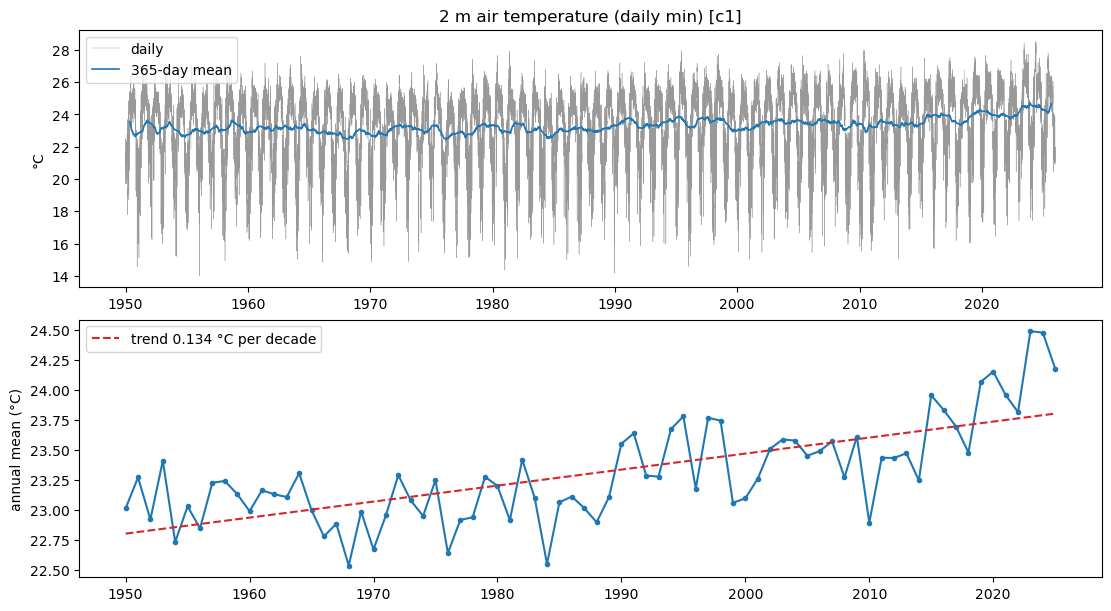

In [79]:
import matplotlib.pyplot as plt

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)

# top: raw daily series with a 1-year running mean
a1.plot(s.index, s.values, lw=0.3, color='0.6', label='daily')
a1.plot(s.rolling(365, center=True, min_periods=300).mean(),
        lw=1.2, color='C0', label='365-day mean')
a1.set_ylabel(UNIT)
a1.set_title(f'{info["label"]} [{TAG}]')
a1.legend(loc='upper left')

# bottom: annual means with the fitted trend
yrs = ann.index.year
a2.plot(yrs, ann.values, 'o-', ms=3, color='C0')
if res is not None:
    a2.plot(yrs, res.intercept + res.slope * yrs, '--', color='C3',
            label=f'trend {res.slope*10:.3f} {UNIT} per decade')
    a2.legend(loc='upper left')
a2.set_ylabel(f'annual mean ({UNIT})')
plt.show()

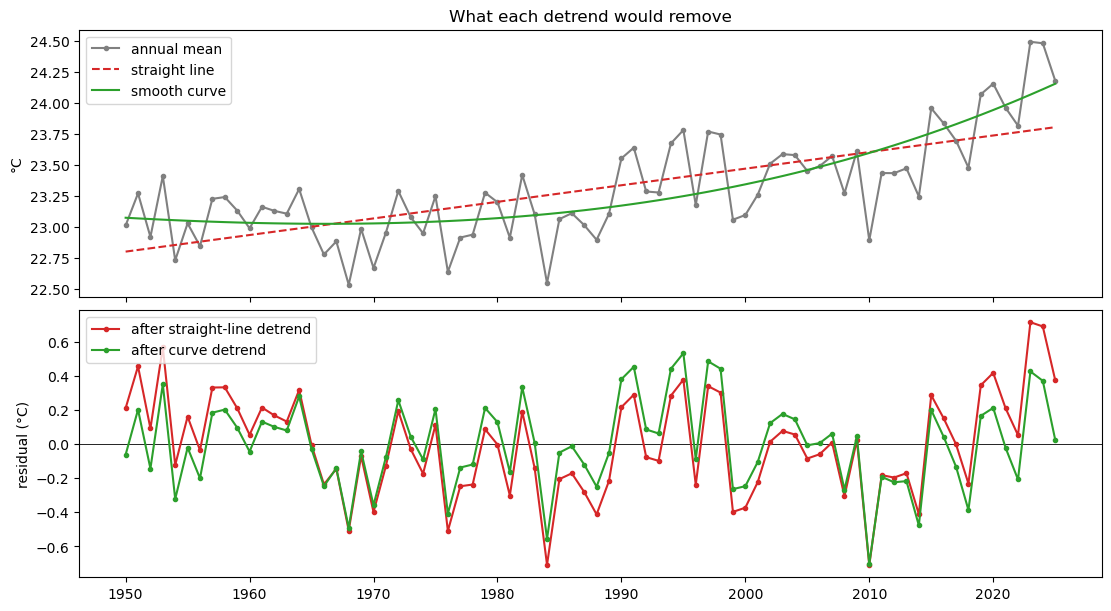

In [80]:
yrs = ann.index.year.values
lin = np.polyval(np.polyfit(yrs, ann.values, 1), yrs)                         # straight line
cur = np.polyval(np.polyfit(yrs - yrs.mean(), ann.values, 3), yrs - yrs.mean())  # smooth curve

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)

# top: what each method would remove
a1.plot(yrs, ann.values, 'o-', ms=3, color='0.5', label='annual mean')
a1.plot(yrs, lin, '--', color='C3', label='straight line')
a1.plot(yrs, cur, '-',  color='C2', label='smooth curve')
a1.set_ylabel(UNIT); a1.legend(loc='upper left')
a1.set_title('What each detrend would remove')

# bottom: what is left after removing it
a2.axhline(0, color='k', lw=0.6)
a2.plot(yrs, ann.values - lin, 'o-', ms=3, color='C3', label='after straight-line detrend')
a2.plot(yrs, ann.values - cur, 'o-', ms=3, color='C2', label='after curve detrend')
a2.set_ylabel(f'residual ({UNIT})'); a2.legend(loc='upper left')
plt.show()

In [81]:
p90 = clim['p90'].reindex(doy365(s.index)).values
exc = pd.Series(s.values > p90, index=s.index)
print(exc.groupby((exc.index.year // 10) * 10).mean().round(3).to_string())

1950    0.047
1960    0.041
1970    0.035
1980    0.051
1990    0.119
2000    0.135
2010    0.137
2020    0.325


In [82]:
sst_e, _ = load_series('sst_c')
sst_h, _ = load_series('temp_surface_c')

print('\nERA5 SST:');  print(sst_e.describe().round(2))
print('\nHYCOM SST:'); print(sst_h.describe().round(2))

print('\nHYCOM days with data per year:')
print(sst_h.groupby(sst_h.index.year).count().to_string())

both = pd.DataFrame({'era5': sst_e, 'hycom': sst_h}).dropna()
print('\noverlap:', both.index[0].date(), 'to', both.index[-1].date(), len(both), 'days')
print('mean difference (HYCOM - ERA5):', round((both.hycom - both.era5).mean(), 2), '°C')
print('daily correlation:', round(both.era5.corr(both.hycom), 2))

Sea surface temperature (ERA5) [sst_c]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
HYCOM bottom level(s) used: [np.float64(4.007843137254902), np.float64(6.488888888888888), np.float64(100.0)] m  <-- should be a single value
Sea surface temperature (HYCOM) [temp_surface_c]: 1992-10-02 to 2024-09-05, 31.9 years, 2156 missing days

ERA5 SST:
count    17167.00
mean        26.44
std          1.73
min         21.55
25%         25.01
50%         26.66
75%         27.88
max         30.53
Name: sst_c, dtype: float64

HYCOM SST:
count    9506.00
mean       26.62
std         2.62
min        18.92
25%        24.47
50%        27.03
75%        28.91
max        31.61
Name: temp_surface_c, dtype: float64

HYCOM days with data per year:
1992     91
1993    364
1994    364
1995    365
1996    332
1997    365
1998    365
1999    365
2000    363
2001    364
2002    365
2003    365
2004    366
2005    365
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013   

In [83]:
d = both.hycom - both.era5
print(d.groupby(d.index.year).agg(['count', 'mean']).round(2).to_string())

      count  mean
1992     91 -0.93
1993    364 -0.24
1994    364 -0.25
1995    365 -0.26
1996    332  0.00
1997    365  0.12
1998    365  0.17
1999    365 -0.06
2000    363 -0.09
2001    364  0.15
2002    365  0.24
2003    365  0.13
2004    366 -0.20
2005    365  0.10
2006    365 -0.03
2007    365  0.25
2008    366  0.12
2009    365  0.16
2010    365  0.10
2011    365  0.19
2012    366  0.16
2017      5  0.29
2018     70 -0.18
2019    365  0.62
2020    366  0.63
2021    365  0.69
2022    365  0.82
2023    365  0.75
2024    249  1.09


In [84]:
u, _  = load_series('wind_u_ms')
v, _  = load_series('wind_v_ms')
ws, _ = load_series('wind_speed_ms')

vec = np.sqrt(u**2 + v**2)          # speed of the daily-average wind
diff = ws - vec

print('\nwind_speed_ms mean:', round(ws.mean(), 2), 'm/s')
print('speed of average u,v mean:', round(vec.mean(), 2), 'm/s')
print('fraction of days where they are equal:', round((diff.abs() < 0.01).mean(), 3))
print('fraction of days where wind_speed_ms is larger:', round((diff > 0.01).mean(), 3))

10 m wind, eastward component [wind_u_ms]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
10 m wind, northward component [wind_v_ms]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
10 m wind speed [wind_speed_ms]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days

wind_speed_ms mean: 6.41 m/s
speed of average u,v mean: 5.61 m/s
fraction of days where they are equal: 0.001
fraction of days where wind_speed_ms is larger: 0.999


In [85]:
from scipy import stats

hmax, _ = load_series('hs_max_m')
yr = hmax.groupby(hmax.index.year)
storms = pd.DataFrame({
    'annual_max_m': yr.max().round(2),
    'days_over_2m': yr.apply(lambda x: (x > 2).sum()),
})
print(storms.to_string())
print('\ntrend in annual max:   ', stats.kendalltau(storms.index, storms['annual_max_m']))
print('trend in days over 2 m:', stats.kendalltau(storms.index, storms['days_over_2m']))

Significant wave height (max) [hs_max_m]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
      annual_max_m  days_over_2m
1979          4.01            21
1980          3.12            18
1981          3.05             6
1982          3.56             9
1983          3.38            14
1984          3.12            14
1985          3.22            19
1986          3.03             9
1987          3.14            17
1988          5.14            22
1989          3.88            16
1990          2.79            14
1991          2.82            11
1992          3.02             9
1993          4.22             9
1994          2.94            17
1995          3.40            20
1996          3.33            23
1997          3.03            16
1998          2.93             8
1999          2.78            11
2000          3.25            14
2001          2.74             6
2002          4.70            28
2003          3.57            16
2004          3.37            14
2005          

In [86]:
sal, _ = load_series('salinity_surface_psu')

print('\n', sal.describe().round(2))
print('\nper year:')
print(sal.groupby(sal.index.year).agg(['count', 'mean']).round(2).to_string())

print('\nmean 1993-2012 (old HYCOM version):', round(sal['1993':'2012'].mean(), 2), 'PSU')
print('mean 2019-2024 (new HYCOM version):', round(sal['2019':'2024'].mean(), 2), 'PSU')

HYCOM bottom level(s) used: [np.float64(4.007843137254902), np.float64(6.488888888888888), np.float64(100.0)] m  <-- should be a single value
Surface salinity [salinity_surface_psu]: 1992-10-02 to 2024-09-05, 31.9 years, 2157 missing days

 count    9505.00
mean       36.43
std         0.23
min        34.04
25%        36.35
50%        36.46
75%        36.56
max        36.92
Name: salinity_surface_psu, dtype: float64

per year:
      count   mean
1992     91  36.30
1993    364  36.31
1994    364  36.44
1995    365  36.29
1996    332  36.43
1997    365  36.39
1998    365  36.38
1999    365  36.30
2000    363  36.43
2001    364  36.39
2002    365  36.27
2003    365  36.43
2004    366  36.41
2005    365  36.38
2006    365  36.42
2007    365  36.40
2008    366  36.45
2009    365  36.46
2010    364  36.43
2011    365  36.38
2012    366  36.43
2013      0    NaN
2014      0    NaN
2015      0    NaN
2016      0    NaN
2017      5  36.59
2018     70  36.59
2019    365  36.62
2020    366  36.52

In [87]:
print(sal[sal < 35])

1995-10-04    34.429459
1995-10-05    34.061929
1995-10-06    34.035192
1995-10-07    34.147302
1995-10-08    34.301047
1995-10-09    34.471612
1995-10-10    34.594588
1995-10-11    34.760067
1995-10-12    34.545216
1995-10-13    34.654776
1995-10-14    34.555000
1995-10-15    34.451341
1995-10-16    34.526969
1995-10-17    34.696059
1995-10-18    34.598922
1995-10-19    34.337914
1995-10-20    34.369831
1995-10-21    34.504337
1995-10-22    34.765718
1995-10-23    34.927510
1995-10-24    34.982404
2002-06-07    34.676443
2002-09-28    34.911055
2002-09-29    34.866106
2002-09-30    34.904094
2005-06-20    34.616765
Name: salinity_surface_psu, dtype: float64


In [88]:
u, _       = load_series('wind_u_ms')
v, _       = load_series('wind_v_ms')
wavedir, _ = load_series('wave_dir_deg')
hmax, _    = load_series('hs_max_m')

wdir = (270 - np.degrees(np.arctan2(v, u))) % 360      # direction the wind comes FROM

names = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
def sector(d):
    d = d.dropna()
    return pd.Series(np.array(names)[(((d + 22.5) % 360) // 45).astype(int)], index=d.index)

def table(d):
    sec = sector(d)
    t = pd.crosstab(sec.index.month, sec, normalize='index') * 100
    return t.reindex(columns=names, fill_value=0).round(0)

print('WIND: % of days from each direction, per month')
print(table(wdir).to_string())
print('\nWAVES: % of days from each direction, per month')
print(table(wavedir).to_string())

storm = sector(wavedir)[hmax > 2]
print('\nSTORM WAVES (max height > 2 m): % from each direction')
print((storm.value_counts(normalize=True) * 100).reindex(names, fill_value=0).round(0).to_string())

10 m wind, eastward component [wind_u_ms]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
10 m wind, northward component [wind_v_ms]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
Mean wave direction (from) [wave_dir_deg]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
Significant wave height (max) [hs_max_m]: 1979-01-01 to 2025-12-31, 47.0 years, 0 missing days
WIND: % of days from each direction, per month
col_0     N    NE     E    SE    S   SW    W   NW
row_0                                            
1      13.0  31.0  42.0  10.0  1.0  0.0  0.0  3.0
2      10.0  28.0  46.0  12.0  1.0  0.0  1.0  2.0
3      10.0  22.0  50.0  15.0  1.0  0.0  0.0  1.0
4       6.0  23.0  58.0  11.0  1.0  0.0  0.0  1.0
5       3.0  25.0  67.0   4.0  0.0  0.0  0.0  1.0
6       1.0  16.0  75.0   6.0  0.0  0.0  1.0  0.0
7       0.0  17.0  80.0   2.0  0.0  0.0  0.0  0.0
8       1.0  21.0  72.0   4.0  1.0  0.0  0.0  0.0
9       3.0  21.0  60.0   8.0  3.0  1.0  2.0  1.0
10      8.0  40.0  

In [89]:
HURDAT = '/Users/sophiethomas/Desktop/MDP/Climatology/hurdat2_atlantic.txt'
SITE = (21.165, -90.03)     # Sisal
RADIUS_KM = 100
YEAR0, YEAR1 = 1950, 2025   # same period as the ERA5-Land baseline

# --- read HURDAT2: one row per 6-hourly track point -------------------------
rows, sid, name = [], None, None
with open(HURDAT) as f:
    for line in f:
        p = [x.strip() for x in line.split(',')]
        if p[0].startswith('AL'):
            sid, name = p[0], p[1]
            continue
        lat = float(p[4][:-1]) * (1 if p[4][-1] == 'N' else -1)
        lon = float(p[5][:-1]) * (-1 if p[5][-1] == 'W' else 1)
        rows.append((sid, name, pd.Timestamp(p[0] + p[1]), p[3], lat, lon, int(p[6])))
trk = pd.DataFrame(rows, columns=['id', 'name', 'time', 'status', 'lat', 'lon', 'wind_kt'])
trk = trk[trk['time'].dt.year.between(YEAR0, YEAR1)]

# --- interpolate to hourly: a fast storm can cross the circle between 6-hourly points
def hourly(g):
    g = g.drop_duplicates('time').set_index('time')
    idx = pd.date_range(g.index[0], g.index[-1], freq='h')
    num = g[['lat', 'lon', 'wind_kt']].reindex(g.index.union(idx)).interpolate('time').reindex(idx)
    num['status'] = g['status'].reindex(idx, method='ffill')
    num['name'] = g['name'].iloc[0]
    return num
h = pd.concat({k: hourly(g) for k, g in trk.groupby('id')}, names=['id', 'time']).reset_index()

# --- distance to Sisal ------------------------------------------------------
la1, lo1 = np.radians(SITE)
la2, lo2 = np.radians(h['lat']), np.radians(h['lon'])
h['km'] = 6371 * 2 * np.arcsin(np.sqrt(np.sin((la2 - la1) / 2)**2
                                       + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2)**2))

# --- tropical/subtropical systems of at least tropical-storm strength (34 kt)
near = h[(h['km'] <= RADIUS_KM) & h['status'].isin(['TS', 'HU', 'SS']) & (h['wind_kt'] >= 34)]

def category(kt):
    for lim, c in [(137, 'Cat 5'), (113, 'Cat 4'), (96, 'Cat 3'), (83, 'Cat 2'), (64, 'Cat 1')]:
        if kt >= lim:
            return c
    return 'TS'

storms = (near.sort_values('km').groupby('id')
              .agg(name=('name', 'first'), date=('time', 'first'),
                   closest_km=('km', 'min'), max_wind_kt=('wind_kt', 'max'))
              .sort_values('date'))
storms['date'] = storms['date'].dt.date
storms[['closest_km', 'max_wind_kt']] = storms[['closest_km', 'max_wind_kt']].round(0)
storms['category'] = storms['max_wind_kt'].apply(category)   # strongest WITHIN the circle, not at Sisal
print(f'Storms within {RADIUS_KM} km of Sisal, {YEAR0}-{YEAR1}: {len(storms)}')
print(storms.to_string())

# --- counts per year and per decade -----------------------------------------
yrs = pd.to_datetime(storms['date']).dt.year
is_hu = storms['category'] != 'TS'
per_year = pd.DataFrame({'all': yrs.value_counts(), 'hurricanes': yrs[is_hu].value_counts()}
                        ).reindex(range(YEAR0, YEAR1 + 1)).fillna(0).astype(int)
dec = (per_year.index // 10) * 10
print('\nstorms per year, by decade:')
print((per_year.groupby(dec).sum() / per_year.groupby(dec).size().values[:, None]).round(2).to_string())
print('\nmean per year, all:', round(per_year['all'].mean(), 2),
      '  hurricanes:', round(per_year['hurricanes'].mean(), 2))
print('trend, all storms:', stats.kendalltau(per_year.index, per_year['all']))
print('trend, hurricanes:', stats.kendalltau(per_year.index, per_year['hurricanes']))

Storms within 100 km of Sisal, 1950-2025: 18
               name        date  closest_km  max_wind_kt category
id                                                               
AL041951    CHARLIE  1951-08-20        12.0         70.0    Cat 1
AL091955      HILDA  1955-09-17        76.0         58.0       TS
AL071956     FLOSSY  1956-09-22        53.0         37.0       TS
AL091966       INEZ  1966-10-07        48.0         93.0    Cat 2
AL131967     BEULAH  1967-09-17        23.0         76.0    Cat 1
AL261969     LAURIE  1969-10-19        83.0         40.0       TS
AL081973     BRENDA  1973-08-20        32.0         52.0       TS
AL011974    UNNAMED  1974-06-25        72.0         35.0       TS
AL101974     CARMEN  1974-09-05        77.0         65.0    Cat 1
AL081988    GILBERT  1988-09-15        29.0        105.0    Cat 3
AL171995       OPAL  1995-10-01        11.0         45.0       TS
AL102002    ISIDORE  2002-09-24        49.0        110.0    Cat 3
AL052005      EMILY  2005-07-18

In [90]:
URL_P = 'https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/MXM00076593.csv'
gp = pd.read_csv(URL_P, parse_dates=['DATE'])
print('columns:', list(gp.columns))

q = gp['TMIN_ATTRIBUTES'].fillna(',,,').str.split(',').str[1]
tmin_p = pd.Series((gp['TMIN'].where(q == '') / 10).values, index=gp['DATE'])   # tenths of °C -> °C
tmin_p = tmin_p.reindex(pd.date_range(tmin_p.index.min(), tmin_p.index.max(), freq='D'))

print(tmin_p.groupby(tmin_p.index.year).agg(['count', 'mean']).round(1).to_string())

columns: ['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'PRCP', 'PRCP_ATTRIBUTES', 'SNWD', 'SNWD_ATTRIBUTES', 'TMAX', 'TMAX_ATTRIBUTES', 'TMIN', 'TMIN_ATTRIBUTES', 'TAVG', 'TAVG_ATTRIBUTES']
      count  mean
1988     12  21.9
1989    229  23.3
1990    333  23.3
1991    322  23.5
1992    324  23.3
1993    238  23.0
1994    195  23.1
1995    188  23.9
1996    241  23.4
1997    228  23.2
1998    152  22.4
1999     64  21.2
2000    363  21.5
2001    365  21.8
2002    365  21.4
2003    365  21.6
2004    243  20.6
2005    242  20.6
2006    243  20.8
2007    182  20.8
2008    366  21.5
2009    212  20.8
2010    301  20.7
2011    364  21.5
2012    366  21.9
2013    329  21.9
2014    331  21.4
2015    338  22.3
2016    335  22.5
2017    341  22.0
2018    325  21.8
2019    320  22.2
2020    283  22.5
2021    239  21.8
2022    240  21.4
2023    239  21.8
2024    243  22.3
2025    343  23.5
2026    254  23.2


In [91]:
emin, _ = load_series('t2m_min_c', 'c1')

d = (tmin_p - emin).dropna()['2000':]                       # Progreso minus ERA5, same days only
d = d - d.groupby(d.index.month).transform('mean')          # remove the normal seasonal difference

print(d.groupby(d.index.year).agg(['count', 'mean']).round(2).to_string())

2 m air temperature (daily min) [t2m_min_c_c1]: 1950-01-02 to 2025-12-31, 76.0 years, 0 missing days
      count  mean
2000    363  0.20
2001    365  0.36
2002    365 -0.26
2003    365 -0.19
2004    243 -0.39
2005    242 -0.47
2006    243 -0.18
2007    182  0.12
2008    366  0.07
2009    212 -0.56
2010    301 -0.56
2011    364 -0.15
2012    366  0.26
2013    329  0.26
2014    331  0.02
2015    338  0.09
2016    335  0.36
2017    341  0.10
2018    325  0.16
2019    320 -0.07
2020    283  0.28
2021    239 -0.25
2022    240 -0.47
2023    239 -0.51
2024    243 -0.20
2025    343  1.07


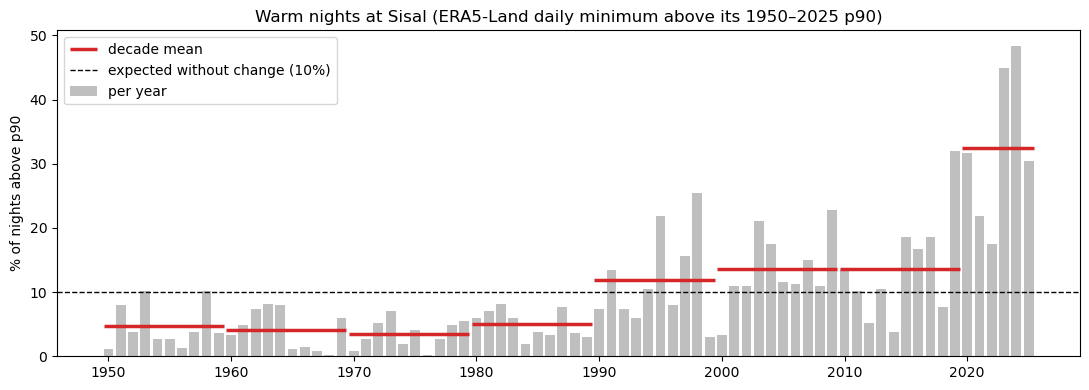

1950     1.1
1951     7.9
1952     3.8
1953    10.1
1954     2.7
1955     2.7
1956     1.4
1957     3.8
1958    10.1
1959     3.6
1960     3.3
1961     4.9
1962     7.4
1963     8.2
1964     7.9
1965     1.1
1966     1.4
1967     0.8
1968     0.3
1969     6.0
1970     0.8
1971     2.7
1972     5.2
1973     7.1
1974     1.9
1975     4.1
1976     0.3
1977     2.7
1978     4.9
1979     5.5
1980     6.0
1981     7.1
1982     8.2
1983     6.0
1984     1.9
1985     3.8
1986     3.3
1987     7.7
1988     3.6
1989     3.0
1990     7.4
1991    13.4
1992     7.4
1993     6.0
1994    10.4
1995    21.9
1996     7.9
1997    15.6
1998    25.5
1999     3.0
2000     3.3
2001    11.0
2002    11.0
2003    21.1
2004    17.5
2005    11.5
2006    11.2
2007    15.1
2008    10.9
2009    22.7
2010    13.4
2011    10.1
2012     5.2
2013    10.4
2014     3.8
2015    18.6
2016    16.7
2017    18.6
2018     7.7
2019    32.1
2020    31.7
2021    21.9
2022    17.5
2023    44.9
2024    48.4
2025    30.4


In [92]:
import matplotlib.pyplot as plt

p90 = clim['p90'].reindex(doy365(s.index)).values
exc = pd.Series(s.values > p90, index=s.index)
yearly = exc.groupby(exc.index.year).mean() * 100                 # % of nights per year
dec = yearly.groupby((yearly.index // 10) * 10).mean()            # decade means

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(yearly.index, yearly.values, color='0.75', label='per year')
for i, (d0, v) in enumerate(dec.items()):
    d1 = min(d0 + 9, yearly.index.max())
    ax.hlines(v, d0 - 0.4, d1 + 0.4, color='C3', lw=2.5,
              label='decade mean' if i == 0 else None)
ax.axhline(10, color='k', ls='--', lw=1, label='expected without change (10%)')
ax.set_ylabel('% of nights above p90')
ax.set_title('Warm nights at Sisal (ERA5-Land daily minimum above its 1950–2025 p90)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(yearly.round(1).to_string())

In [93]:
import xarray, netCDF4
print('xarray', xarray.__version__, ' netCDF4', netCDF4.__version__)

xarray 2026.2.0  netCDF4 1.7.4
